In [23]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
from visualizations import flatmap_real_vals 
import seaborn as sns

In [2]:
dataset_name = 'MDTB' # or Demand

projectPath, mainResultsPath = setProjectPath()
resultsPath = os.path.join(mainResultsPath, 'START_A2_gse_decomposition', dataset_name)
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
PKL_output = os.path.join(resultsPath, f'{dataset_name}_output.pkl') 

In [3]:
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

## visualize voxel-wise vs / (vs + vg) for the whole cortex

In [4]:
result = output['whole_cortex']['voxel_wise']   # columns in the order: vg, vs, ve 
voxel_wise_cortex = np.divide(result[:, 1].reshape((-1, 1)), np.sum(result[:, 0:2], axis=1, keepdims=True)) 

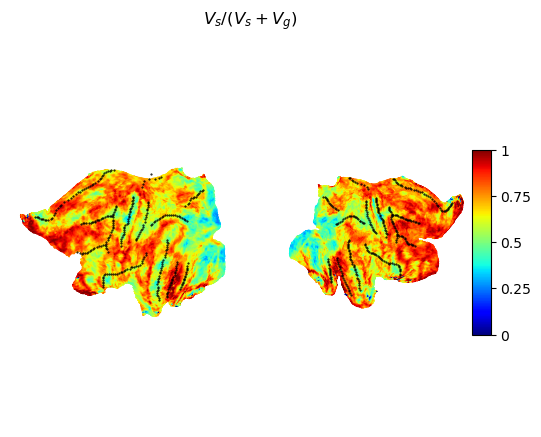

In [7]:
plt.subplot(1, 2, 1)
flatmap_real_vals(voxel_wise_cortex, hemi='L', cscale=[0, 1], cmap='jet') 
plt.subplot(1, 2, 2)
flatmap_real_vals(voxel_wise_cortex, hemi='R', cscale=[0, 1], cmap='jet', colorbar=True)  
plt.suptitle('$V_s/(V_s+V_g)$')
# plt.tight_layout()

PS_variance = os.path.join(resultsPath, f'{dataset_name}_flatmap_v_s_gs.jpg')
if os.path.exists(PS_variance):
    os.remove(PS_variance)
plt.savefig(PS_variance, format='jpg', dpi=500)

## vs/(vs + vg) in whole cortex, PFC, visual, somatosensory and parietal regions

In [14]:
ROIs = ['PFC', 'visual', 'somatosensory', 'parietal']
n_rois = len(ROIs)
props = [] 

for roiI in np.arange(n_rois):
    result = np.array(output[ROIs[roiI]]['global'])  
    prop = np.divide(result[:,1], result[:,0]+result[:,1])
    props.append(prop) 

props = np.array(props)     # n_rois x n_bootstraps, each element is vs/(vs+vg) 

In [32]:
props.std(axis=1)  

array([0.01192594, 0.00903269, 0.02058674, 0.02080509])

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 72.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 74.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 55.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 56.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.0, '$V_s/(V_s + V_g)$')

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 72.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 74.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 54.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 55.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


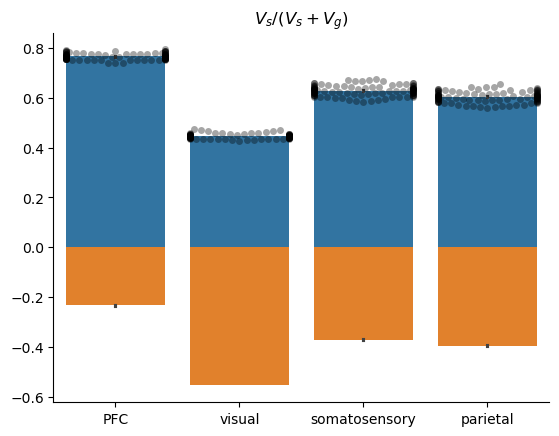

In [35]:
ax = sns.barplot(props.T, errorbar='se', color='tab:blue')      # bar plot for the mean of vs 
sns.barplot(props.T - 1, errorbar='se', color='tab:orange')     # bar plot for the mean of vg
sns.swarmplot(props.T, color='0', alpha=0.35)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(n_rois), labels=ROIs)
ax.set_title('$V_s/(V_s + V_g)$') 


In [ ]:


ax.set_ylabel('percentage') 
ax.set_ylim([-0.1, 1.1])
ax.set_yticks(np.arange(0, 1.1, 0.2)) 
ax.hlines(y=0, xmin=-0.5, xmax=n_rois-0.5, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.hlines(y=1, xmin=-0.5, xmax=n_rois-0.5, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.text(0, -0.05, 'group', color=(150/255, 150/255, 150/255))
ax.text(0, 0.95, 'individual', color=(150/255, 150/255, 150/255))


JPG_fig = os.path.join(resultsPath, f'variance_decomposition_bar_plot.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In PFC, group variance accounts for 24% out of total explainable variance, while individual variance accounts for 76%. 

In [24]:
tips = sns.load_dataset("tips")


In [25]:
tips 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:

sns.barplot(x="day", y="total_bill", data=tips, capsize=.1, ci="sd")
sns.swarmplot(x="day", y="total_bill", data=tips, color="0", alpha=.35)

plt.show()